# Análisis exploratorio de incidencia delictiva en México

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

#### Ejercicio 1: Elige 3 estados de la república y grafica una serie de tiempo de la frecuencia absoluta de homicidios dolosos de enero 2015 a julio 2019 en estas tres entidades

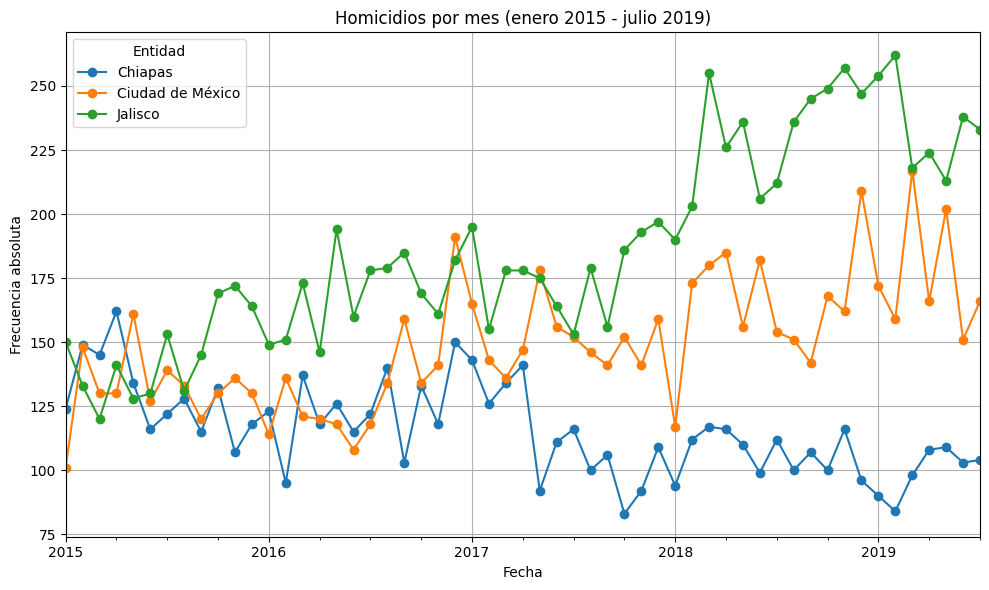

In [27]:
homicidios = df[df['tipo_de_delito'].str.contains('Homicidio', case=False, na=False)].copy()
homicidios['fecha'] = pd.to_datetime(homicidios['fecha'])
start = '2015-01-01'
end = '2019-07-31'

homicidios = homicidios[(homicidios['fecha'] >= start) & (homicidios['fecha'] <= end)]
estados = ['Chiapas', 'Jalisco', 'Ciudad de México']

h3 = homicidios[homicidios['entidad'].isin(estados)]
h3['frecuencia'] = pd.to_numeric(h3['frecuencia'], errors='coerce')

serie = h3.groupby(['fecha','entidad'])['frecuencia'].sum().unstack()
serie.plot(figsize=(10,6), marker='o')
plt.title('Homicidios por mes (enero 2015 - julio 2019)')
plt.ylabel('Frecuencia absoluta')
plt.xlabel('Fecha')
plt.grid(True)
plt.legend(title='Entidad')
plt.tight_layout()

#### Ejercicio 2: Contetas las siguientes  preguntas:
1. ¿Cuántos homicidios dolosos hubo en Colima en el 2018?
2. ¿Cuantos robos de vehículo automotor ha habido en el 2019?
3. Obten la suma de homicidos dolosos y feminidios en toda la República Mexicana en cada año.
4. ¿En qué mes y en qué municipio ha ocurrido el mayor número de feminicidios?
5. ¿En qué año y en qué estado ha ocurrido el mayor número de feminicidios?

In [40]:
# 1. homicidios dolosos en Colima 2018
mask1 = (df['tipo_de_delito'].str.contains('Homicidio', case=False, na=False)) & \
        (df['entidad'] == 'Colima') & \
        (df['anio'] == 2018)
colima_2018 = df.loc[mask1, 'frecuencia'].astype(float).sum()
print('Homicidios dolosos en Colima 2018:', int(colima_2018))

# 2. robos de vehículo automotor en 2019
mask2 = (df['tipo_de_delito'].str.contains('Robo', case=False, na=False)) & \
        (df['anio'] == 2019)
robos_2019 = df.loc[mask2, 'frecuencia'].astype(float).sum()
print('Robos de vehículo automotor en 2019:', int(robos_2019))

# 3. suma de homicidios dolosos + feminidios por año
mask3 = df['tipo_de_delito'].isin(['Homicidio', 'Feminicidio'])
suma_hom_fem = df.loc[mask3].groupby('anio')['frecuencia'].sum().astype(int)
print('\nSuma de homicidios dolosos y feminicidios por año:')
print(suma_hom_fem)

# 4. mes y estado máximo feminicidios
print('\n\n4. Mes y estado con mayor número de feminicidios:')
fem = df[df['tipo_de_delito'] == 'Feminicidio']
max_row = fem.loc[fem['frecuencia'].idxmax()]
print('Mes:', max_row['nombre_mes'])
print('Estado:', max_row['entidad'])
print('Frecuencia:', int(max_row['frecuencia']))

# 5. año y estado con mayor feminicidios acumulados
print('\n\n5. Año y estado con total más alto de feminicidios:')
fem_by_year_state = fem.groupby(['anio','entidad'])['frecuencia'].sum()
best = fem_by_year_state.idxmax()
best_val = fem_by_year_state.max()
print('Año:', best[0])
print('Estado:', best[1])
print('Total feminicidios:', int(best_val))

Homicidios dolosos en Colima 2018: 726
Robos de vehículo automotor en 2019: 766096

Suma de homicidios dolosos y feminicidios por año:
anio
2015    31744
2016    36018
2017    42068
2018    45385
2019    45822
2020    44223
2021    44960
2022    43845
2023    42846
2024    22307
Name: frecuencia, dtype: int64


4. Mes y estado con mayor número de feminicidios:
Mes: julio
Estado: México
Frecuencia: 19


5. Año y estado con total más alto de feminicidios:
Año: 2020
Estado: México
Total feminicidios: 151


#### Ejercicio 3: Haz una gráfica de pastel de tipos de delito. Deberás crear una gráfica para cada año. Utiliza la función subplots de matplotlib

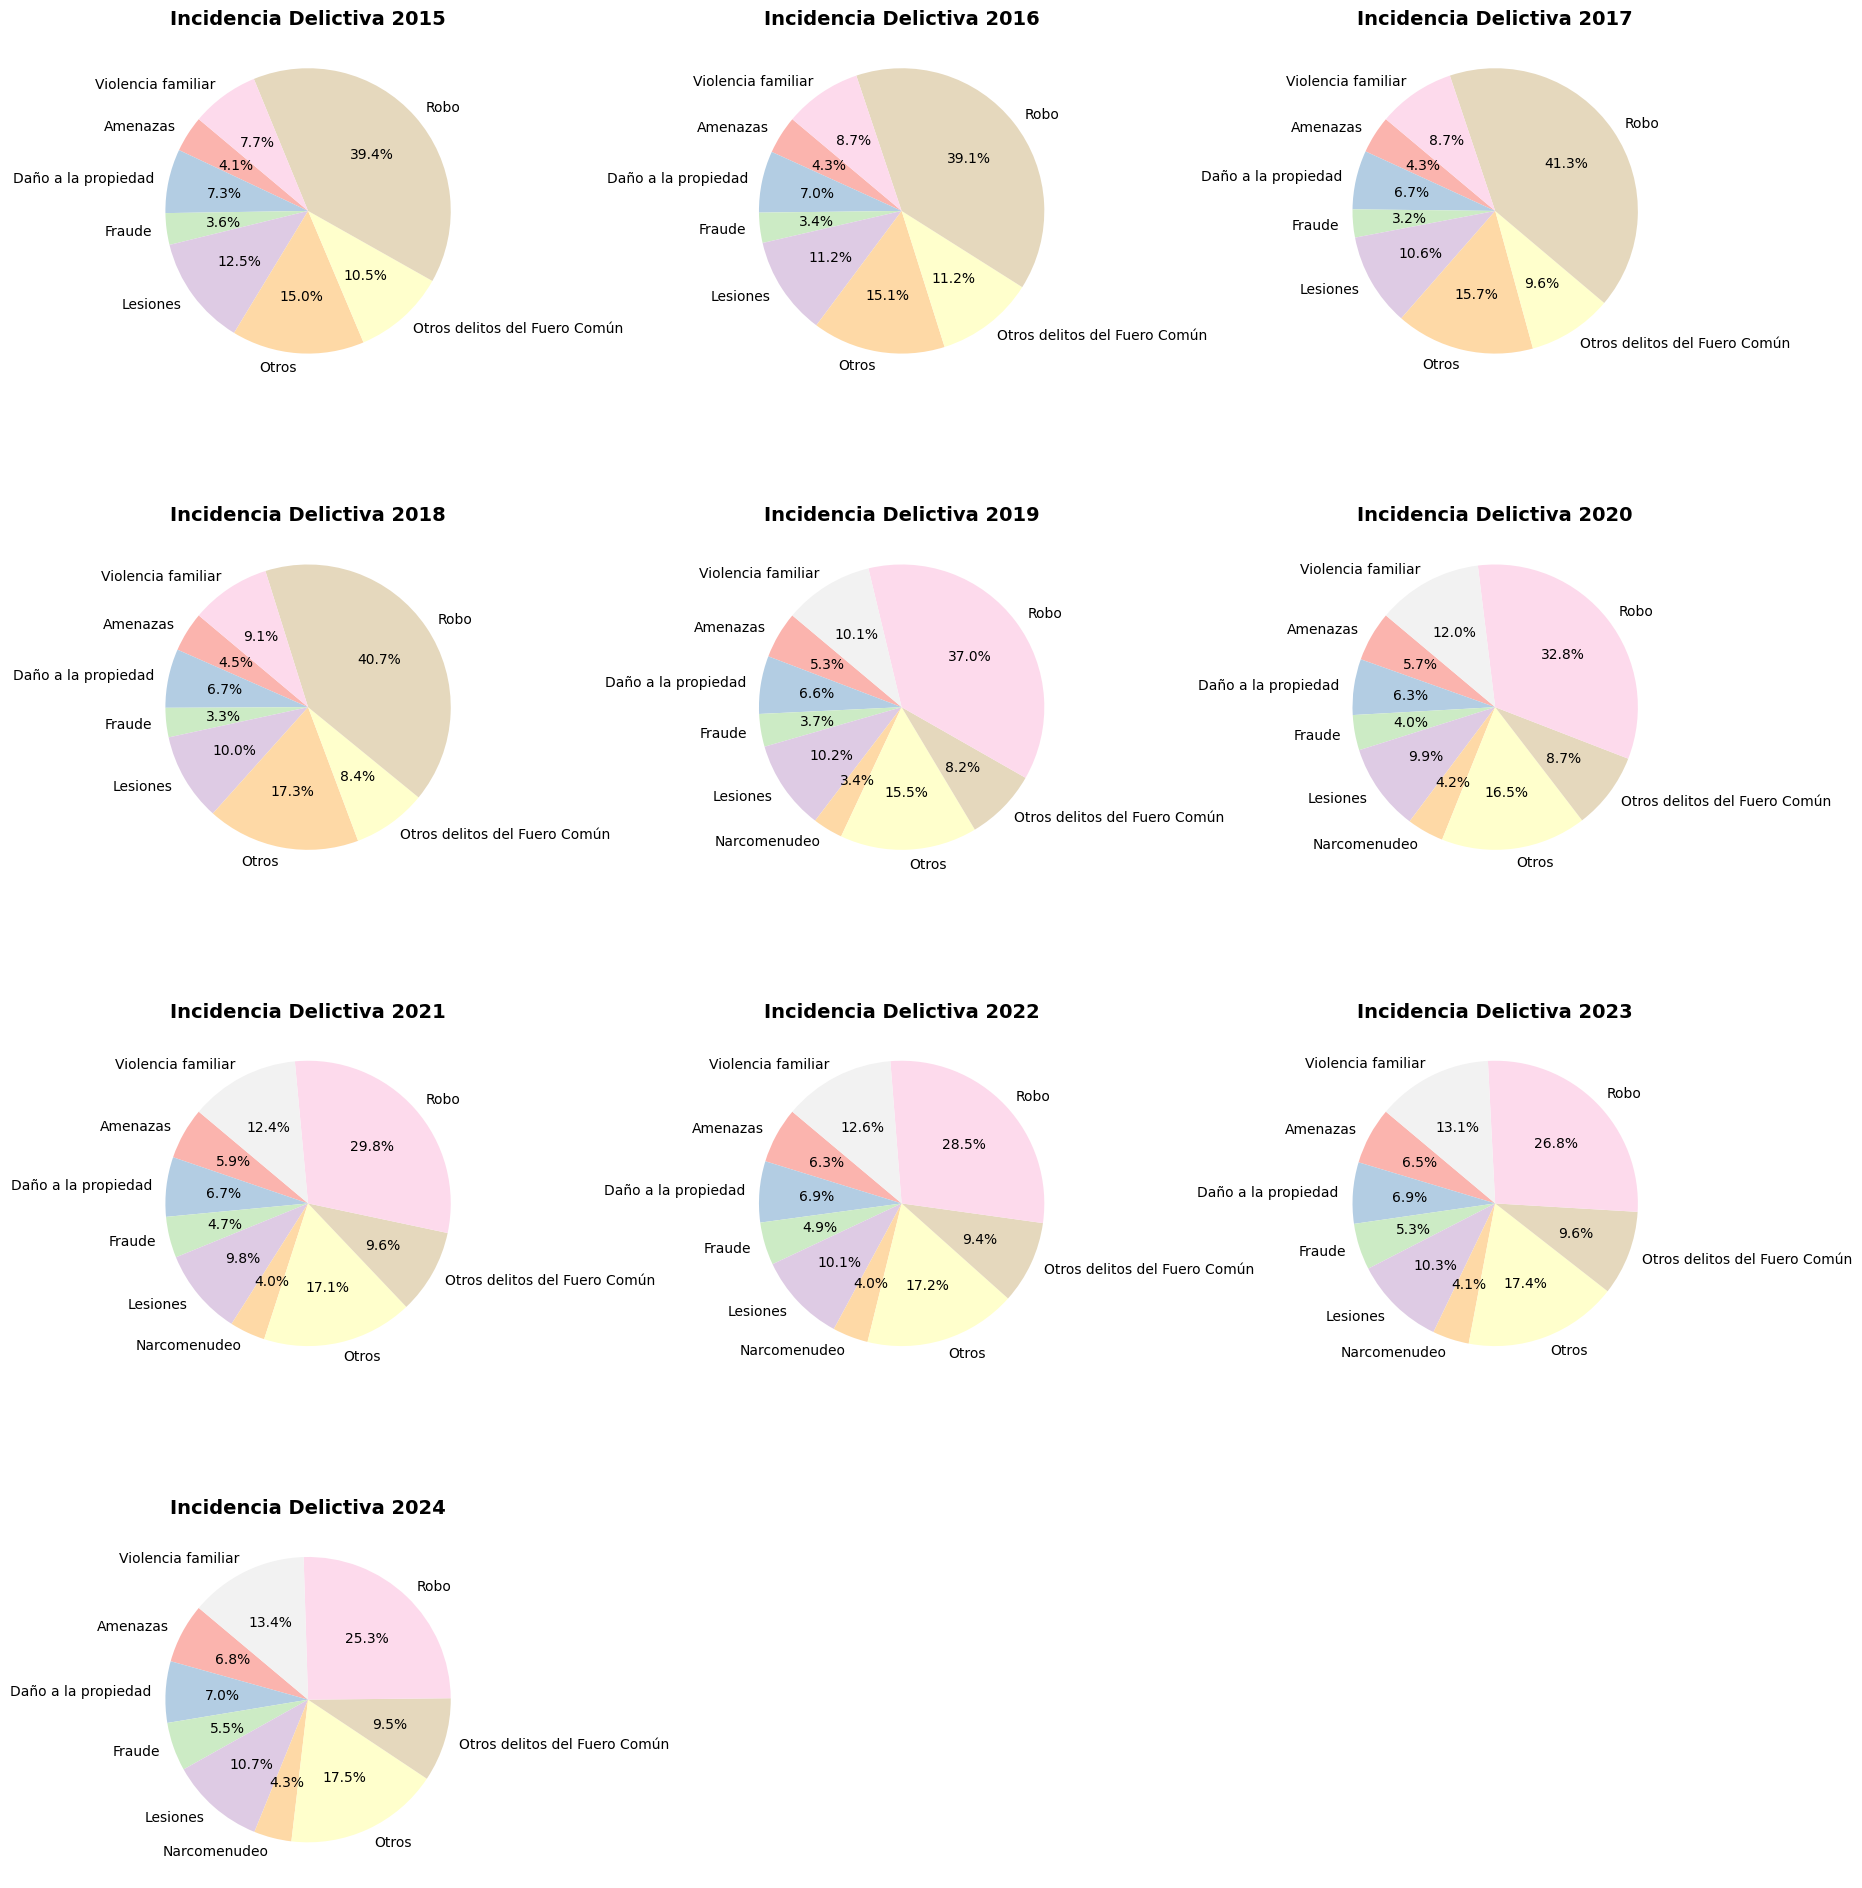

In [57]:
resumen = df.groupby(['anio', 'tipo_de_delito'])['frecuencia'].sum().reset_index()

anios = sorted(resumen['anio'].unique())
n_anios = len(anios)
cols = 3
rows = (n_anios + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(18, 5 * rows))
axes = axes.flatten()

for i, anio in enumerate(anios):
    data_anio = resumen[resumen['anio'] == anio].copy()
    
    total_anio = data_anio['frecuencia'].sum()
    umbral = total_anio * 0.03
    
    data_anio.loc[data_anio['frecuencia'] < umbral, 'tipo_de_delito'] = 'Otros'
    data_final = data_anio.groupby('tipo_de_delito')['frecuencia'].sum()

    axes[i].pie(data_final, 
                labels=data_final.index, 
                autopct='%1.1f%%', 
                startangle=140,
                colors=plt.cm.Pastel1.colors)
    axes[i].set_title(f'Incidencia Delictiva {anio}', fontsize=14, fontweight='bold')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

---
#### Calcula la tasa por 100,000 habitantes
##### Tasa por 100,000 habitantes
Mostrar el total de delitos en una entidad no nos sirve de mucho. Es mucho más útil calcular la tasa de incidencia delictiva por cada 100,000 habitantes

$$
tasa = \frac{delitos\space totales}{población} \times 100,000
$$

Esta tasa la podemos anualizar multiplicándola por un factor de 12
$$
tasa\space anualizada = tasa \times 12
$$

Población por entidad federativa según [la encuesta intercensal 2015](https://www.inegi.org.mx/programas/intercensal/2015/)

No tienes que descargar nada. Ya están los datos en la carpeta data

In [ ]:
pobs = pd.read_csv('data/poblacion_entidades_2015.csv', encoding='iso-8859-1', sep=";")
pobs = pobs[['Cve_Entidad', 'Entidad', 'Poblacion']]
pobs = pobs.rename(columns={'Cve_Entidad':'clave_entidad', 'Entidad':'entidad', 'Poblacion':'poblacion'})
pobs.head()

,clave_entidad,entidad,poblacion
0,1,Aguascalientes,1312544.0
1,2,Baja California,3315766.0
2,3,Baja California Sur,712029.0
3,4,Campeche,899931.0
4,5,Coahuila de Zaragoza,5217908.0
